# Lab 7: Movement & Networks

## Part 1 Networks and spatial networks
### 1.1 Project folders

In [1]:
from pathlib import Path

DATA = Path("data/raw")
OUT = Path("outputs")
FIG = OUT / "figs"

for p in [DATA, OUT, FIG]:
    p.mkdir(parents=True, exist_ok=True)

print("Folders ready:", DATA, OUT, FIG)

Folders ready: data/raw outputs outputs/figs


### 1.2 Download OpenFlights (airports + routes)

In [2]:
import urllib.request
from pathlib import Path

airports_url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat"
routes_url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat"

airports_path = Path("data/raw/airports.dat")
routes_path = Path("data/raw/routes.dat")

urllib.request.urlretrieve(airports_url, airports_path)
urllib.request.urlretrieve(routes_url, routes_path)

print("Downloaded:", airports_path, routes_path)

Downloaded: data/raw/airports.dat data/raw/routes.dat


### 1.3 Load tables + basic inspection

In [3]:
import pandas as pd

airports_cols = "airport_id,name,city,country,iata,icao,lat,lon,alt,tz,dst,tz_db,type,source".split(",")
routes_cols = "airline,airline_id,src_iata,src_id,dst_iata,dst_id,codeshare,stops,equipment".split(",")

airports = pd.read_csv("data/raw/airports.dat", header=None, names=airports_cols)
routes = pd.read_csv("data/raw/routes.dat", header=None, names=routes_cols)

print("airport:", airports.shape)
airports[["iata", "name", "country", "lat", "lon"]].head()


airport: (7698, 14)


,iata,name,country,lat,lon
0,GKA,Goroka Airport,Papua New Guinea,-6.081690,145.391998
1,MAG,Madang Airport,Papua New Guinea,-5.207080,145.789001
2,HGU,Mount Hagen Kagamuga Airport,Papua New Guinea,-5.826790,144.296005
3,LAE,Nadzab Airport,Papua New Guinea,-6.569803,146.725977
4,POM,Port Moresby Jacksons International Airport,Papua New Guinea,-9.443380,147.220001


In [4]:
print("routes:", routes.shape)
routes[["src_iata", "dst_iata", "stops"]].head()

routes: (67663, 9)


,src_iata,dst_iata,stops
0,AER,KZN,0
1,ASF,KZN,0
2,ASF,MRV,0
3,CEK,KZN,0
4,CEK,OVB,0


### 1.4 Clean + build a graph (NetworkX)

In [5]:
import networkx as nx

# Clean (OpenFlights uses literal string "\N" for missing codes)
for c in ["src_iata", "dst_iata"]:
    routes[c] = routes[c].astype(str)

mask = (
    routes["src_iata"].notna()
    & routes["dst_iata"].notna()
    & (routes["src_iata"] != r"\N")
    & (routes["dst_iata"] != r"\N")
    & (routes["src_iata"].str.len() > 0)
    & (routes["dst_iata"].str.len() > 0)
)

routes2 = routes.loc[mask, ["src_iata", "dst_iata"]].copy()

# drop self-loops
routes2 = routes2[routes2["src_iata"] != routes2["dst_iata"]]

# Aggregate to OD counts (edge weight)
od = (
    routes2.groupby(["src_iata", "dst_iata"], as_index=False)
    .size()
    .rename(columns={"size": "flow"})
)

# Build weighted directed graph
G = nx.from_pandas_edgelist(
    od,
    source="src_iata",
    target="dst_iata",
    edge_attr="flow",
    create_using=nx.DiGraph(),
)

print("Graph nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

# Keep a manageable subgraph for centrality (top N by degree)
deg = dict(G.degree())
top_nodes = sorted(deg, key=deg.get, reverse=True)[:200]
H = G.subgraph(top_nodes).copy()

print("Subgraph nodes:", H.number_of_nodes(), "edges:", H.number_of_edges())

Graph nodes: 3425 edges: 37594
Subgraph nodes: 200 edges: 8965


In [ ]:
deg_G = dict(G.degree())
top_deg_node = max(deg_G, key=deg_G.get)

bw = nx.betweenness_centrality(G, normalized=True)
top_bw_node = max(bw, key=bw.get)

In [15]:
print("Graph nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())
print("Top degree node:", top_deg_node, "degree:", deg_G[top_deg_node])
print("Top betweenness node:", top_bw_node, "betweenness:", bw[top_bw_node])

Graph nodes: 3425 edges: 37594
Top degree node: FRA degree: 477
Top betweenness node: ANC betweenness: 0.07020362618341769


### 1.5 Non-spatial network visualization

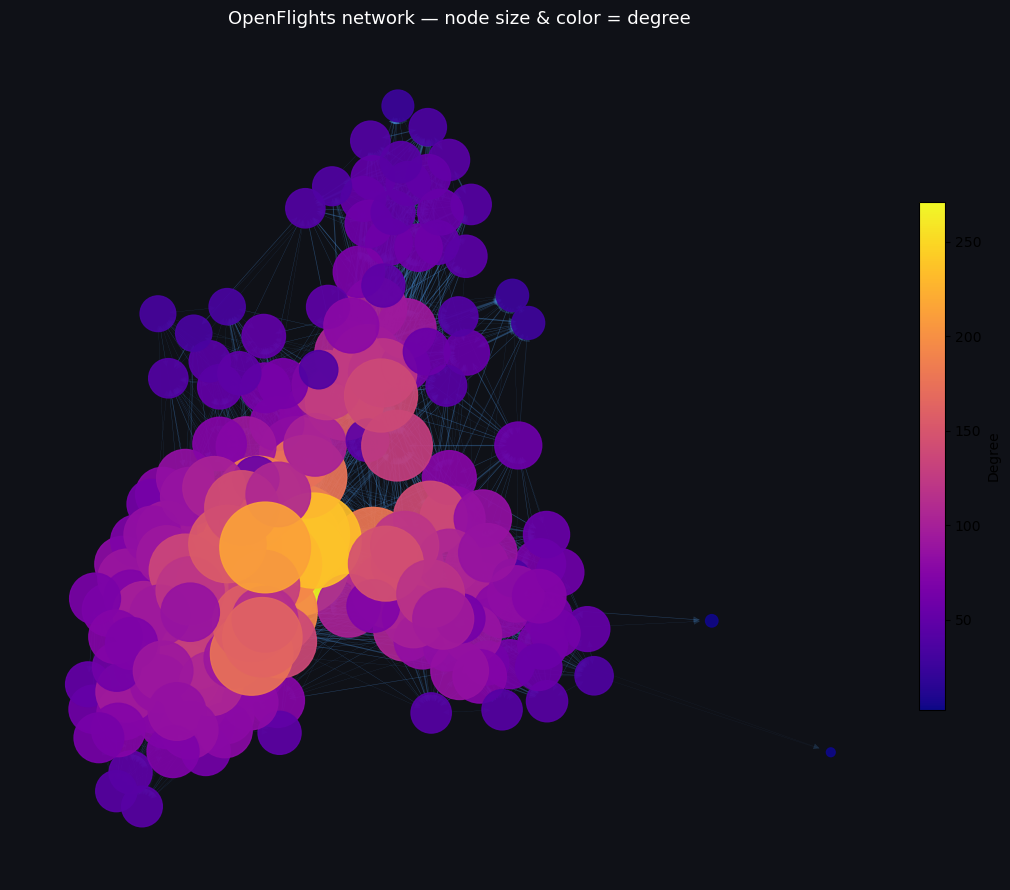

Saved: outputs/figs/network_nonspatial.png


In [ ]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(H, seed=7, k=0.25)

# ── Visual design knobs (try changing these) ──────────────────────
node_size_scale = 20      # larger = bigger nodes
edge_width_scale = 0.12   # larger = thicker edges
node_alpha = 0.92
edge_alpha = 0.20
bg_color = "#0f1117"      # dark background; try "white" for print
node_cmap = "plasma"      # try "viridis", "cool", "YlOrRd"
edge_color = "#4a90d9"    # try "white" or "gray"
# ─────────────────────────────────────────────────────────────────

deg_H = dict(H.degree())

node_sizes = [deg_H[n] * node_size_scale for n in H.nodes()]
node_colors = [deg_H[n] for n in H.nodes()]  # color encodes degree
edge_widths = [H[u][v]["flow"] * edge_width_scale for u, v in H.edges()]

fig, ax = plt.subplots(figsize=(11, 9), facecolor=bg_color)
ax.set_facecolor(bg_color)

nx.draw_networkx_edges(
    H,
    pos,
    ax=ax,
    width=edge_widths,
    alpha=edge_alpha,
    edge_color=edge_color,
)

nc = nx.draw_networkx_nodes(
    H,
    pos,
    ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=node_cmap,
    alpha=node_alpha,
)

sm = plt.cm.ScalarMappable(
    cmap=node_cmap,
    norm=plt.Normalize(min(node_colors), max(node_colors)),
)
plt.colorbar(sm, ax=ax, shrink=0.6, label="Degree", pad=0.01)

ax.set_title(
    "OpenFlights network — node size & color = degree",
    color="white",
    fontsize=13,
)

ax.axis("off")

out = "outputs/figs/network_nonspatial.png"

plt.tight_layout()
plt.savefig(out, dpi=200, facecolor=bg_color)
plt.show()

print("Saved:", out)

### 1.6 Highlight the highest-degree node and highest-betweenness node

Top degree node: AMS degree: 271
Top betweenness node: AMS betweenness: 0.07450395635756939


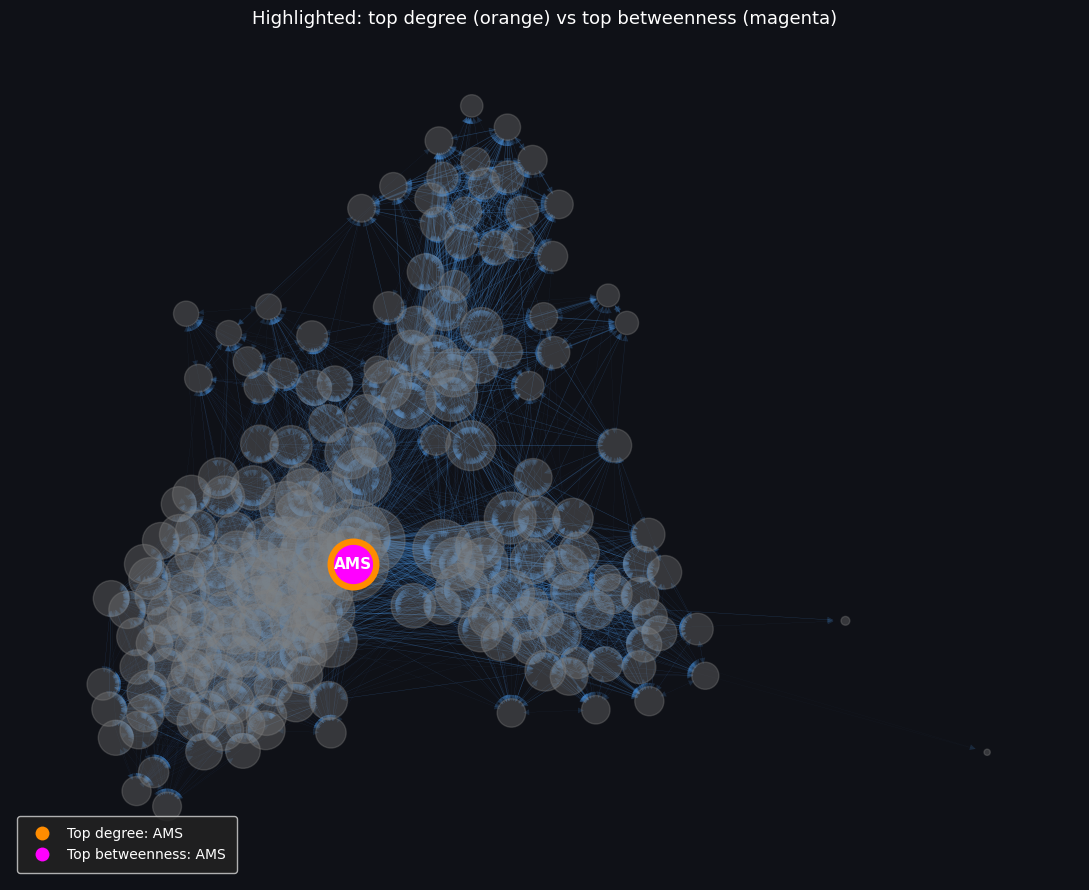

Saved: outputs/figs/network_highlight.png
Same node is top in both metrics.


In [28]:
deg_H = dict(H.degree())
top_deg_node = max(deg_H, key=deg_H.get)

# Betweenness (undirected for readability)
bw = nx.betweenness_centrality(H.to_undirected(), normalized=True)
top_bw_node = max(bw, key=bw.get)

print("Top degree node:", top_deg_node, "degree:", deg_H[top_deg_node])
print("Top betweenness node:", top_bw_node, "betweenness:", bw[top_bw_node])

# ── Visual design knobs ──────────────────────────────────────────────
bg = "#0f1117"           # background color
color_deg = "#FF8C00"    # orange — top degree node
color_bw = "#FF00FF"     # magenta — top betweenness node
hl_node_size = 1200      # size of the two highlighted nodes
deg_node_size = 1400
bw_node_size = 800
legend_ms = 10           # legend marker size (pts)
node_size_scale = 10      # larger = bigger nodes
edge_width_scale = 0.08   # larger = thicker edges
# ─────────────────────────────────────────────────────────────────────

from matplotlib.lines import Line2D

node_sizes = [deg_H[n] * node_size_scale for n in H.nodes()]
edge_widths = [H[u][v]["flow"] * edge_width_scale for u, v in H.edges()]

fig, ax = plt.subplots(figsize=(11, 9), facecolor=bg)
ax.set_facecolor(bg)

# Base network
nx.draw_networkx_edges(
    H,
    pos,
    ax=ax,
    width=edge_widths,
    alpha=0.18,
    edge_color="#4a90d9",
)

nx.draw_networkx_nodes(
    H,
    pos,
    ax=ax,
    node_size=node_sizes,
    node_color="gray",
    alpha=0.35,
)

# Highlight top degree node
nx.draw_networkx_nodes(
    H,
    pos,
    ax=ax,
    nodelist=[top_deg_node],
    node_size=deg_node_size,
    node_color=color_deg,
    linewidths=0,
    edgecolors="white",
)

# Highlight top betweenness node
nx.draw_networkx_nodes(
    H,
    pos,
    ax=ax,
    nodelist=[top_bw_node],
    node_size=bw_node_size,
    node_color=color_bw,
    linewidths=0,
    edgecolors="white",
)

# Labels for highlighted nodes
nx.draw_networkx_labels(
    H,
    pos,
    ax=ax,
    labels={
        top_deg_node: top_deg_node,
        top_bw_node: top_bw_node,
    },
    font_size=11,
    font_color="white",
    font_weight="bold",
)

# Custom legend (small markers)
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=color_deg,
        markeredgecolor="white",
        markeredgewidth=0,
        markersize=legend_ms,
        label=f"Top degree: {top_deg_node}",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=color_bw,
        markeredgecolor="white",
        markeredgewidth=0,
        markersize=legend_ms,
        label=f"Top betweenness: {top_bw_node}",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="lower left",
    fontsize=10,
    facecolor="#222",
    labelcolor="white",
    framealpha=0.85,
    borderpad=0.8,
)

ax.set_title(
    "Highlighted: top degree (orange) vs top betweenness (magenta)",
    color="white",
    fontsize=13,
)

ax.axis("off")

out = "outputs/figs/network_highlight.png"

plt.tight_layout()
plt.savefig(out, dpi=200, facecolor=bg)
plt.show()

print("Saved:", out)

if top_deg_node == top_bw_node:
    print("Same node is top in both metrics.")

### 1.7 Download + visualize a spatial road network (OSMnx)

Geocoded place OK: Manhattan, New York City, New York, USA
Road nodes: (4628, 6)
Road edges: (9916, 15)


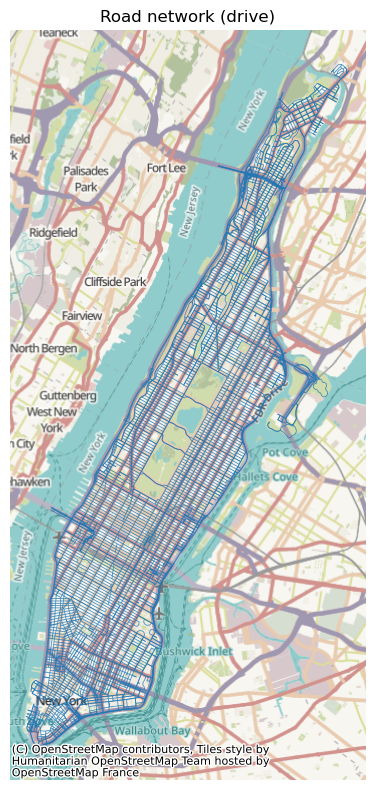

Saved: outputs/figs/road_network.png


In [35]:
import os
import osmnx as ox
import contextily as ctx
import matplotlib.pyplot as plt

ox.settings.log_console = True
ox.settings.use_cache = True
ox.settings.timeout = 180

# Tip: Change PLACE to try a different city/region
PLACE_CANDIDATES = [
    "Manhattan, New York City, New York, USA",
    "New York City, New York, USA",
    "Seattle, Washington, USA",
]

network_type = "drive"

# 1) Try place -> polygon, then fallback to point+radius
polygon = None

for place in PLACE_CANDIDATES:
    try:
        gdf_place = ox.geocode_to_gdf(place)
        if len(gdf_place) > 0:
            polygon = gdf_place.geometry.iloc[0]
            print("Geocoded place OK:", place)
            break
    except Exception as e:
        print("Geocode failed:", place, "|", type(e).__name__, e)

if polygon is not None:
    G_road = ox.graph_from_polygon(
        polygon,
        network_type=network_type,
        simplify=True,
    )
else:
    print("Fallback: graph_from_point (no geocode results).")

    # Example point (NYC-ish). Change as needed.
    center_latlon = (40.7580, -73.9855)
    dist_m = 1000

    G_road = ox.graph_from_point(
        center_latlon,
        dist=dist_m,
        network_type=network_type,
        simplify=True,
    )

# 2) Project + convert to GeoDataFrames
G_road = ox.project_graph(G_road)
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_road)

print("Road nodes:", nodes_gdf.shape)
print("Road edges:", edges_gdf.shape)

# 3) Plot + basemap (contextily wants Web Mercator)
edges_web = edges_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))
edges_web.plot(ax=ax, linewidth=0.6, alpha=0.8)

ctx.add_basemap(ax, crs=edges_web.crs)

ax.set_title("Road network (drive)")
ax.set_axis_off()

os.makedirs("outputs/figs", exist_ok=True)
out = "outputs/figs/road_network.png"

plt.tight_layout()
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

### 1.8 Accessibility demo (shortest path)

Origin node: 42423296
Nearest hospital node: 42453934
Distance (meters): 3275.1120901825866


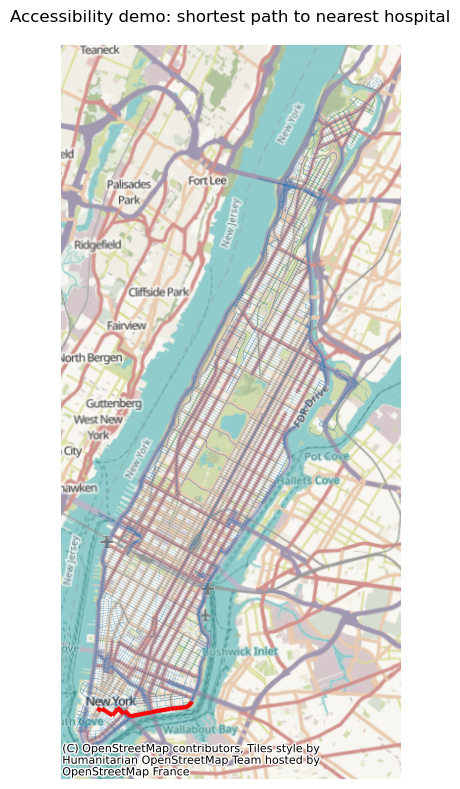

Saved: outputs/figs/accessibility.png


In [59]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

# 1) Origin location
# origin_latlon = ox.geocode(place)  # (lat, lon)
origin_latlon = (40.75858550977049, -73.97691463583527)
origin_latlon = gpd.GeoSeries(
    [Point(origin_latlon[1], origin_latlon[0])],
    crs="EPSG:4326"
).to_crs(nodes_gdf.crs)
origin_latlon = (origin_latlon.iloc[0].x, origin_latlon.iloc[0].y)
orig_node = ox.nearest_nodes(
    G_road,
    X=origin_latlon[1],
    Y=origin_latlon[0],
)

print("Origin node:", orig_node)

# 2) Get hospital locations
hosp = ox.features_from_place(
    place,
    tags={"landuse": "retail"},
).to_crs(nodes_gdf.crs)

# Use centroids in case polygons
hosp_pts = hosp.geometry.centroid

# 3) Convert hospital points to nearest graph nodes
target_nodes = [
    ox.nearest_nodes(G_road, X=p.x, Y=p.y)
    for p in hosp_pts
]

# 4) Compute shortest path distances
dists = [
    nx.shortest_path_length(
        G_road,
        orig_node,
        t,
        weight="length",
    )
    for t in target_nodes
]

# 5) Identify nearest hospital
best_index = int(np.argmin(dists))
best_t = target_nodes[best_index]
best_dist = float(np.min(dists))

print("Nearest hospital node:", best_t)
print("Distance (meters):", best_dist)

# 6) Extract shortest path
route = nx.shortest_path(
    G_road,
    orig_node,
    best_t,
    weight="length",
)

route_gdf = ox.routing.route_to_gdf(G_road, route)

# 7) Plot
fig, ax = plt.subplots(figsize=(10, 8))

edges_gdf.plot(ax=ax, linewidth=0.4, alpha=0.4)
route_gdf.plot(ax=ax, linewidth=3, color="red")

ctx.add_basemap(ax, crs=edges_gdf.crs)

ax.set_title("Accessibility demo: shortest path to nearest hospital")
ax.set_axis_off()

out = "outputs/figs/accessibility.png"

plt.tight_layout()
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

## Part 2 Origin-Destination (OD) flow visualization
### 2.1 Build an OD table (from routes) + join coordinates

In [60]:
import os
import pandas as pd

# Clean airports table (OpenFlights uses literal string "\N")
air = airports[["iata", "lat", "lon", "name", "country"]].copy()

air["iata"] = air["iata"].astype(str)

mask = (
    air["iata"].notna()
    & (air["iata"] != r"\N")
    & (air["iata"].str.len() > 0)
)

air = air.loc[mask].drop_duplicates("iata").copy()

air["lat"] = pd.to_numeric(air["lat"], errors="coerce")
air["lon"] = pd.to_numeric(air["lon"], errors="coerce")

# Join OD flows with origin/destination airport coordinates
od2 = (
    od
    .merge(
        air.add_prefix("o_"),
        left_on="src_iata",
        right_on="o_iata",
        how="left",
    )
    .merge(
        air.add_prefix("d_"),
        left_on="dst_iata",
        right_on="d_iata",
        how="left",
    )
)

# Drop rows where coordinates are missing
od2 = od2.dropna(subset=["o_lat", "o_lon", "d_lat", "d_lon"]).copy()

print("OD rows after join:", od2.shape)

# Save output
os.makedirs("outputs", exist_ok=True)
out_csv = "outputs/od_flows.csv"

od2.to_csv(out_csv, index=False)

print("Saved:", out_csv)

OD rows after join: (37041, 13)
Saved: outputs/od_flows.csv


### 2.2 OD data checks (shape, missing, distribution, symmetry, coverage)

In [66]:
import numpy as np
import matplotlib.pyplot as plt

df = od2.copy()

In [62]:
print("df.shape:", df.shape)
print(df.dtypes)

df.shape: (37041, 13)
src_iata         str
dst_iata         str
flow           int64
o_iata           str
o_lat        float64
o_lon        float64
o_name           str
o_country        str
d_iata           str
d_lat        float64
d_lon        float64
d_name           str
d_country        str
dtype: object


In [63]:
print(df.isnull().sum())
print(df["flow"].describe())

src_iata     0
dst_iata     0
flow         0
o_iata       0
o_lat        0
o_lon        0
o_name       0
o_country    0
d_iata       0
d_lat        0
d_lon        0
d_name       0
d_country    0
dtype: int64
count    37041.000000
mean         1.806998
std          1.285356
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         20.000000
Name: flow, dtype: float64


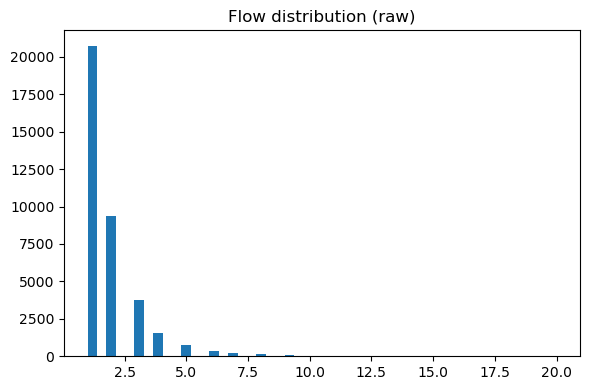

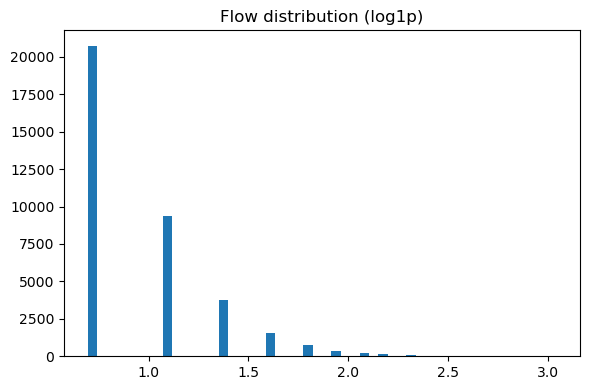

In [64]:
# Raw distribution
plt.figure(figsize=(6, 4))
plt.hist(df["flow"], bins=50)
plt.title("Flow distribution (raw)")
plt.tight_layout()
plt.show()

# Log-transformed distribution
plt.figure(figsize=(6, 4))
plt.hist(np.log1p(df["flow"]), bins=50)
plt.title("Flow distribution (log1p)")
plt.tight_layout()
plt.show()

In [65]:
# --- Symmetry check (A→B vs B→A) ---

rev = df.rename(
    columns={
        "src_iata": "dst_iata",
        "dst_iata": "src_iata",
        "flow": "flow_rev",
    }
)

sym = df.merge(
    rev[["src_iata", "dst_iata", "flow_rev"]],
    on=["src_iata", "dst_iata"],
    how="left",
)

sym["diff"] = sym["flow"] - sym["flow_rev"].fillna(0)

print("Symmetry check (diff summary):")
print(sym["diff"].describe())

print(
    "Unique origins:",
    df["src_iata"].nunique(),
    "Unique dests:",
    df["dst_iata"].nunique(),
)

print(
    "Lat range:",
    (df["o_lat"].min(), df["o_lat"].max()),
    "Lon range:",
    (df["o_lon"].min(), df["o_lon"].max()),
)

Symmetry check (diff summary):
count    37041.000000
mean         0.025890
std          0.318447
min         -6.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.000000
Name: diff, dtype: float64
Unique origins: 3241 Unique dests: 3240
Lat range: (np.float64(-54.8433), np.float64(78.246101379395)) Lon range: (np.float64(-179.876998901), np.float64(179.341003418))


### 2.3 Flow map (geographic)

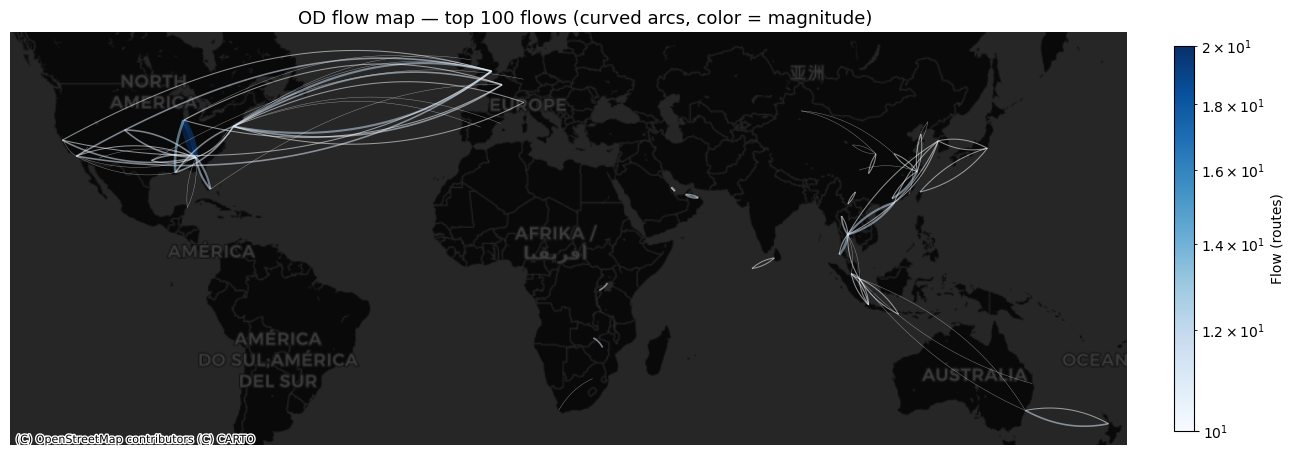

Saved: outputs/figs/od_flow_map.png


In [72]:
import geopandas as gpd
from shapely.geometry import LineString
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

N = 100
df_top = df.sort_values("flow", ascending=False).head(N).copy()

# ---- Curved arc function (quadratic Bezier) ----
def curved_line(o_lon, o_lat, d_lon, d_lat, n_pts=40, bulge=0.15):
    mid_lon = (o_lon + d_lon) / 2 + bulge * (d_lat - o_lat)
    mid_lat = (o_lat + d_lat) / 2 - bulge * (d_lon - o_lon)

    t = np.linspace(0, 1, n_pts)

    lons = (1 - t) ** 2 * o_lon + 2 * (1 - t) * t * mid_lon + t ** 2 * d_lon
    lats = (1 - t) ** 2 * o_lat + 2 * (1 - t) * t * mid_lat + t ** 2 * d_lat

    return LineString(zip(lons, lats))


# Create curved geometries
lines = [
    curved_line(r.o_lon, r.o_lat, r.d_lon, r.d_lat)
    for r in df_top.itertuples()
]

gdf_lines = (
    gpd.GeoDataFrame(df_top, geometry=lines, crs="EPSG:4326")
    .to_crs("EPSG:3857")
)

# ── Visual design knobs ─────────────────────────────────────────────
cmap_name = "Blues"  # try "plasma", "cool", "Blues"
alpha = 0.55
# ────────────────────────────────────────────────────────────────────

# Line width scaling (log scaled)
log_flow = np.log1p(gdf_lines["flow"])

gdf_lines["w_plot"] = (
    0.3
    + 3.5
    * (log_flow - log_flow.min())
    / (log_flow.max() - log_flow.min())
)

# Color mapping
cmap = plt.get_cmap(cmap_name)

norm = mcolors.LogNorm(
    vmin=gdf_lines["flow"].min() + 1,
    vmax=gdf_lines["flow"].max(),
)

colors = [cmap(norm(f)) for f in gdf_lines["flow"]]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(14, 8))

for (_, row), color in zip(gdf_lines.iterrows(), colors):
    gpd.GeoDataFrame(
        [row],
        geometry="geometry",
        crs=gdf_lines.crs,
    ).plot(
        ax=ax,
        linewidth=row["w_plot"],
        alpha=alpha,
        color=color,
    )

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, shrink=0.5, label="Flow (routes)", pad=0.01)

ctx.add_basemap(
    ax,
    crs=gdf_lines.crs,
    source=ctx.providers.CartoDB.DarkMatter,
)

ax.set_title(
    f"OD flow map — top {N} flows (curved arcs, color = magnitude)",
    fontsize=13,
)

ax.set_axis_off()

out = "outputs/figs/od_flow_map.png"

plt.tight_layout()
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

### 2.4 Chord diagram (top airports)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
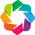

:Chord   [src_iata,dst_iata]   (flow)

In [82]:
# Option A: holoviews chord (interactive in Jupyter)

import pandas as pd
import holoviews as hv
from holoviews import opts

hv.extension("bokeh")

K = 10

# 1) Top-K airports by total outbound flow
topK = (
    df.groupby("src_iata")["flow"]
    .sum()
    .sort_values(ascending=False)
    .head(K)
    .index
)

dfK = df[
    df["src_iata"].isin(topK)
    & df["dst_iata"].isin(topK)
].copy()

# 2) Build edges and nodes
flow_threshold = 5
edges = dfK.loc[
    dfK["flow"] >= flow_threshold,
    ["src_iata", "dst_iata", "flow"]]

nodes = pd.DataFrame({
    "iata": sorted(
        set(edges["src_iata"]).union(edges["dst_iata"])
    )
})

# 3) Create chord diagram
ch = hv.Chord(
    (
        edges,
        hv.Dataset(nodes, "iata"),
    )
).opts(
    opts.Chord(
        labels="iata",
        edge_color="src_iata",
        node_color="iata",
        edge_alpha=0.6,
        node_size=10,
        width=650,
        height=650,
        title=f"Chord diagram (top {K} airports, flow threshold={flow_threshold})",
    )
)

ch

### 2.5 OD matrix (heatmap)

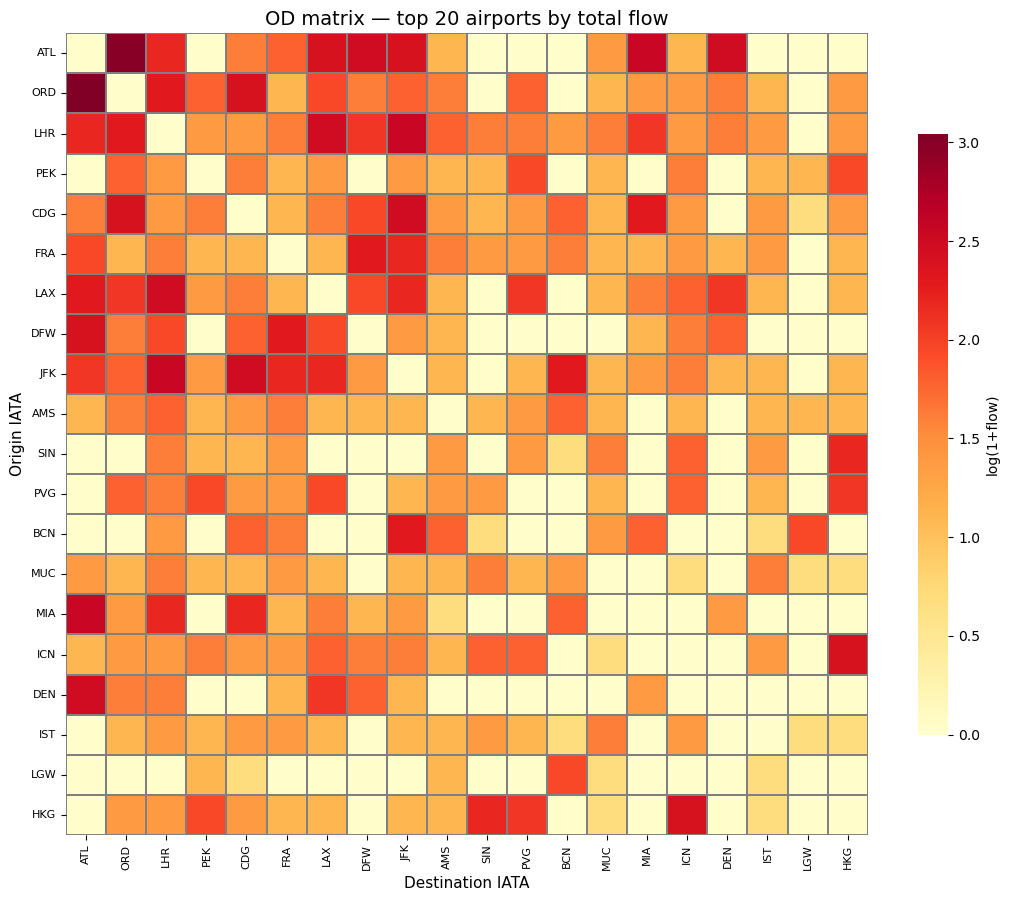

Saved: outputs/figs/od_matrix.png


In [85]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

K = 20

# 1) Top-K airports by total outbound flow
topK = (
    df.groupby("src_iata")["flow"]
    .sum()
    .sort_values(ascending=False)
    .head(K)
    .index
)

dfK = df[
    df["src_iata"].isin(topK)
    & df["dst_iata"].isin(topK)
].copy()

# 2) Build OD matrix
mat = (
    dfK.pivot_table(
        index="src_iata",
        columns="dst_iata",
        values="flow",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(index=topK, columns=topK, fill_value=0)
)

# ── Visual design knobs ─────────────────────────────────────────────
cmap_name = "YlOrRd"   # try "YlOrRd", "Blues", "RdYlGn_r"
use_log = True        # log-transform to reveal structure in heavy tails
# ────────────────────────────────────────────────────────────────────

mat_plot = np.log1p(mat) if use_log else mat
cb_label = "log(1+flow)" if use_log else "flow"

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    mat_plot,
    ax=ax,
    cmap=cmap_name,
    linewidths=0.3,
    linecolor="gray",
    square=True,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": cb_label, "shrink": 0.75},
)

ax.set_title(
    f"OD matrix — top {K} airports by total flow",
    fontsize=14,
)

ax.set_xlabel("Destination IATA", fontsize=11)
ax.set_ylabel("Origin IATA", fontsize=11)

ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)

out = "outputs/figs/od_matrix.png"

plt.tight_layout()
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

## Part 3 Trajectories (GPS tracks)
### 3.1 Load trajectory data

In [86]:
# ──────────────────────────────────────────────────────────────────────────
# Road-following synthetic GPS trajectories WITH stop events
# REQUIRES: G_road, nodes_gdf, edges_gdf
# ──────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
from shapely.geometry import LineString

rng = np.random.default_rng(42)

N_TRAJ = 6
PING_INTERVAL_S = 15
GPS_NOISE_M = 8
GAP_PROB = 0.08
STOP_PROB = 0.50
MIN_STOPS = 2
STOP_DUR_RANGE = (45, 150)


def sample_route_pings(
    G, nodes_gdf, src, dst,
    ping_s, noise_m, gap_p,
    stop_p, min_s, stop_dur,
    rng, tid, base_t
):

    try:
        path_nodes = nx.shortest_path(G, src, dst, weight="length")
    except nx.NetworkXNoPath:
        return []

    if len(path_nodes) < 3:
        return []

    coords = []
    node_dists = [0.0]
    cumlen = 0.0

    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        ed = G[u][v]
        if isinstance(ed, dict) and 0 in ed:
            ed = ed[0]

        geom = ed.get("geometry", None)

        if geom is not None:
            seg = list(geom.coords)
            coords.extend(seg)
            cumlen += LineString(seg).length
        else:
            p1 = (nodes_gdf.loc[u].geometry.x, nodes_gdf.loc[u].geometry.y)
            p2 = (nodes_gdf.loc[v].geometry.x, nodes_gdf.loc[v].geometry.y)
            coords.extend([p1, p2])
            cumlen += np.hypot(p2[0] - p1[0], p2[1] - p1[1])

        node_dists.append(cumlen)

    route_line = LineString(coords)
    total_len = route_line.length
    mid_dists = node_dists[1:-1]

    # --- Stop selection ---
    stop_mask = [rng.random() < stop_p for _ in mid_dists]

    if mid_dists and sum(stop_mask) < min_s:
        off_idx = [i for i, m in enumerate(stop_mask) if not m]
        rng.shuffle(off_idx)
        for i in off_idx[: max(0, min_s - sum(stop_mask))]:
            stop_mask[i] = True

    stop_events = {
        mid_dists[i]: int(rng.integers(stop_dur[0], stop_dur[1]))
        for i, m in enumerate(stop_mask) if m
    }

    speed_ms = rng.uniform(15, 30) / 3.6
    step = speed_ms * ping_s

    rows = []
    dist = 0.0
    t_sec = 0.0
    fired = set()

    while dist < total_len:

        # Inject stop if close to stop location
        for stop_dist, stop_secs in stop_events.items():
            if stop_dist not in fired and abs(dist - stop_dist) < step * 0.55:

                fired.add(stop_dist)
                n_sp = max(1, stop_secs // ping_s)

                pt_s = route_line.interpolate(stop_dist)
                gs_s = gpd.GeoSeries([pt_s], crs=nodes_gdf.crs).to_crs("EPSG:4326")
                slon0, slat0 = gs_s.iloc[0].x, gs_s.iloc[0].y

                nd = noise_m * 1e-5

                for _ in range(n_sp):
                    if rng.random() > gap_p:
                        t = base_t + pd.Timedelta(seconds=t_sec)
                        rows.append(
                            (
                                f"T{tid:02d}",
                                t,
                                slat0 + rng.normal(0, nd * 0.15),
                                slon0 + rng.normal(0, nd * 0.15),
                            )
                        )
                    t_sec += ping_s
                break

        # Normal moving ping
        pt = route_line.interpolate(dist)
        gs = gpd.GeoSeries([pt], crs=nodes_gdf.crs).to_crs("EPSG:4326")
        lon0, lat0 = gs.iloc[0].x, gs.iloc[0].y

        nd = noise_m * 1e-5

        if rng.random() > gap_p:
            t = base_t + pd.Timedelta(seconds=t_sec)
            rows.append(
                (
                    f"T{tid:02d}",
                    t,
                    lat0 + rng.normal(0, nd),
                    lon0 + rng.normal(0, nd),
                )
            )

        dist += step
        t_sec += ping_s + int(rng.integers(0, 5))

    return rows


# ──────────────────────────────────────────────────────────
# Generate trajectories
# ──────────────────────────────────────────────────────────

all_nodes = list(G_road.nodes())
rows_all = []
base_t = pd.Timestamp("2024-06-15 08:00:00")

for tid in range(N_TRAJ):

    for _ in range(60):
        src, dst = rng.choice(all_nodes, size=2, replace=False)

        try:
            plen = nx.shortest_path_length(G_road, src, dst, weight="length")
        except nx.NetworkXNoPath:
            continue

        if plen > 500:
            break

    offset = pd.Timedelta(minutes=int(rng.integers(0, 20)))

    rows_all.extend(
        sample_route_pings(
            G_road,
            nodes_gdf,
            src,
            dst,
            PING_INTERVAL_S,
            GPS_NOISE_M,
            GAP_PROB,
            STOP_PROB,
            MIN_STOPS,
            STOP_DUR_RANGE,
            rng,
            tid,
            base_t + offset,
        )
    )

df = pd.DataFrame(rows_all, columns=["traj_id", "t", "lat", "lon"])

print(
    f"Generated {df['traj_id'].nunique()} trajectories, {len(df)} pings"
)
print(
    f"noise: {GPS_NOISE_M}m | interval: {PING_INTERVAL_S}s | "
    f"gap: {GAP_PROB:.0%} | stop_prob: {STOP_PROB:.0%} | "
    f"min_stops: {MIN_STOPS}"
)

df_traj = df.copy()
df_traj["t"] = pd.to_datetime(df_traj["t"])

print(df_traj.head())
print("traj_id unique:", df_traj["traj_id"].nunique())
print("rows:", df_traj.shape[0])

Generated 6 trajectories, 1860 pings
noise: 8m | interval: 15s | gap: 8% | stop_prob: 50% | min_stops: 2
  traj_id                   t        lat        lon
0     T00 2024-06-15 08:08:00  40.849543 -73.936269
1     T00 2024-06-15 08:08:18  40.848985 -73.935271
2     T00 2024-06-15 08:08:36  40.848664 -73.934142
3     T00 2024-06-15 08:08:51  40.848024 -73.932857
4     T00 2024-06-15 08:09:06  40.848033 -73.932866
traj_id unique: 6
rows: 1860


### 3.2 Trajectory checks (count, gaps, speeds, lengths, coverage)

In [88]:
import numpy as np

# 1) Sort by trajectory and time
df_traj = df_traj.sort_values(["traj_id", "t"]).copy()

# 2) Temporal gaps
df_traj["dt_s"] = (
    df_traj.groupby("traj_id")["t"]
    .diff()
    .dt.total_seconds()
)

print("Temporal gaps (seconds) summary:")
print(df_traj["dt_s"].describe())

Temporal gaps (seconds) summary:
count    1854.000000
mean       16.840885
std         5.168925
min        15.000000
25%        15.000000
50%        15.000000
75%        15.750000
max        64.000000
Name: dt_s, dtype: float64


In [89]:
# 3) Haversine distance function
def haversine_m(lon1, lat1, lon2, lat2):
    R = 6371000  # Earth radius in meters

    lon1, lat1, lon2, lat2 = map(
        np.radians,
        [lon1, lat1, lon2, lat2],
    )

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


# 4) Previous coordinates
df_traj["lon_prev"] = (
    df_traj.groupby("traj_id")["lon"]
    .shift()
)

df_traj["lat_prev"] = (
    df_traj.groupby("traj_id")["lat"]
    .shift()
)

# 5) Distance between consecutive pings
df_traj["dist_m"] = haversine_m(
    df_traj["lon_prev"],
    df_traj["lat_prev"],
    df_traj["lon"],
    df_traj["lat"],
)

# 6) Speed (km/h)
df_traj["speed_kmh"] = (
    df_traj["dist_m"] / df_traj["dt_s"]
) * 3.6

print("Speed (km/h) summary:")
print(df_traj["speed_kmh"].describe())

Speed (km/h) summary:
count    1854.000000
mean        6.079316
std         8.719911
min         0.012170
25%         0.376847
50%         0.720050
75%        11.709351
max        40.128404
Name: speed_kmh, dtype: float64


In [90]:
# 7) Trajectory-level summary
by = df_traj.groupby("traj_id").agg(
    n_points=("t", "size"),
    duration_min=("dt_s", lambda s: np.nansum(s) / 60),
    dist_km=("dist_m", lambda s: np.nansum(s) / 1000),
)

print(by.describe())

print("Lat range:", (df_traj["lat"].min(), df_traj["lat"].max()))
print("Lon range:", (df_traj["lon"].min(), df_traj["lon"].max()))

         n_points  duration_min    dist_km
count    6.000000      6.000000   6.000000
mean   310.000000     86.730556   9.518495
std    163.292376     45.333910   5.042381
min     62.000000     17.700000   1.698754
25%    205.750000     58.029167   6.512306
50%    358.500000    100.008333  11.990691
75%    433.250000    121.225000  12.416131
max    468.000000    130.333333  14.186712
Lat range: (np.float64(40.71726645913961), np.float64(40.84954274817162))
Lon range: (np.float64(-73.99473711963964), np.float64(-73.930735528945))


### 3.3 Map matching (snap to road network) - before/after

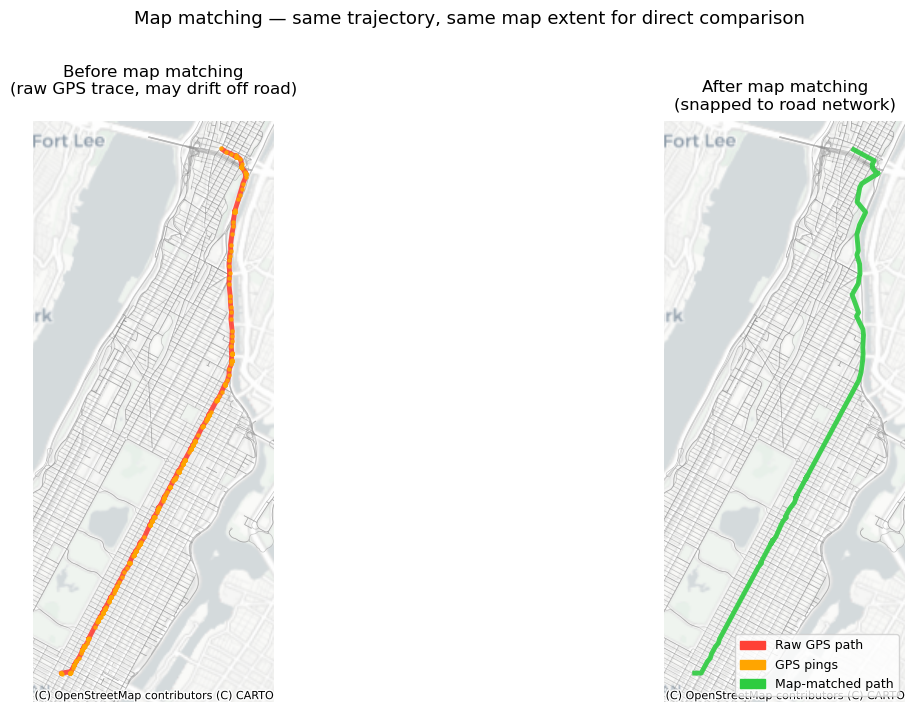

Saved: outputs/figs/mapmatch_before_after.png


In [91]:
import geopandas as gpd
from shapely.geometry import Point, LineString
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1) Pick one trajectory
one_id = df_traj["traj_id"].iloc[0]
t0 = df_traj[df_traj["traj_id"] == one_id].copy()

# 2) Raw GPS points → GeoDataFrame
gpts = (
    gpd.GeoDataFrame(
        t0,
        geometry=[Point(xy) for xy in zip(t0.lon, t0.lat)],
        crs="EPSG:4326",
    )
    .to_crs(edges_gdf.crs)
)

# 3) Snap each GPS point to nearest road node
snapped_nodes = [
    ox.nearest_nodes(G_road, X=pt.x, Y=pt.y)
    for pt in gpts.geometry
]

snapped_xy = [
    (
        nodes_gdf.loc[n].geometry.x,
        nodes_gdf.loc[n].geometry.y,
    )
    for n in snapped_nodes
]

# 4) Build raw and snapped LineStrings
raw_line = LineString(list(gpts.geometry))
snap_line = LineString(snapped_xy)

graw = gpd.GeoSeries([raw_line], crs=edges_gdf.crs)
gsnap = gpd.GeoSeries([snap_line], crs=edges_gdf.crs)

# ── Side-by-side panels ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, gline, color, title in zip(
    axes,
    [graw, gsnap],
    ["#FF4136", "#2ECC40"],  # red = raw, green = snapped
    [
        "Before map matching\n(raw GPS trace, may drift off road)",
        "After map matching\n(snapped to road network)",
    ],
):

    edges_gdf.plot(
        ax=ax,
        linewidth=0.5,
        alpha=0.45,
        color="#888",
    )

    gline.plot(
        ax=ax,
        linewidth=3.5,
        alpha=0.9,
        color=color,
    )

    # Show GPS pings only on "before" panel
    if color == "#FF4136":
        gpts.plot(
            ax=ax,
            markersize=5,
            color="orange",
            alpha=0.8,
            zorder=5,
        )

    ctx.add_basemap(
        ax,
        crs=edges_gdf.crs,
        source=ctx.providers.CartoDB.Positron,
    )

    ax.set_title(title, fontsize=12, pad=8)
    ax.set_axis_off()

# 5) Lock both panels to same extent
xmin, ymin, xmax, ymax = graw.total_bounds
pad = (xmax - xmin) * 0.15

for ax in axes:
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)

# 6) Legend
patches = [
    mpatches.Patch(color="#FF4136", label="Raw GPS path"),
    mpatches.Patch(color="orange", label="GPS pings"),
    mpatches.Patch(color="#2ECC40", label="Map-matched path"),
]

axes[1].legend(
    handles=patches,
    loc="lower right",
    fontsize=9,
)

fig.suptitle(
    "Map matching — same trajectory, same map extent for direct comparison",
    fontsize=13,
    y=1.01,
)

out = "outputs/figs/mapmatch_before_after.png"

plt.tight_layout()
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out)

### 3.4 Gap filling (optional) - before/after

Before rows: 331 After rows: 556


/var/folders/ww/h0dqmsqj3r950ks4z5vgln280000gn/T/ipykernel_36440/2130903666.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


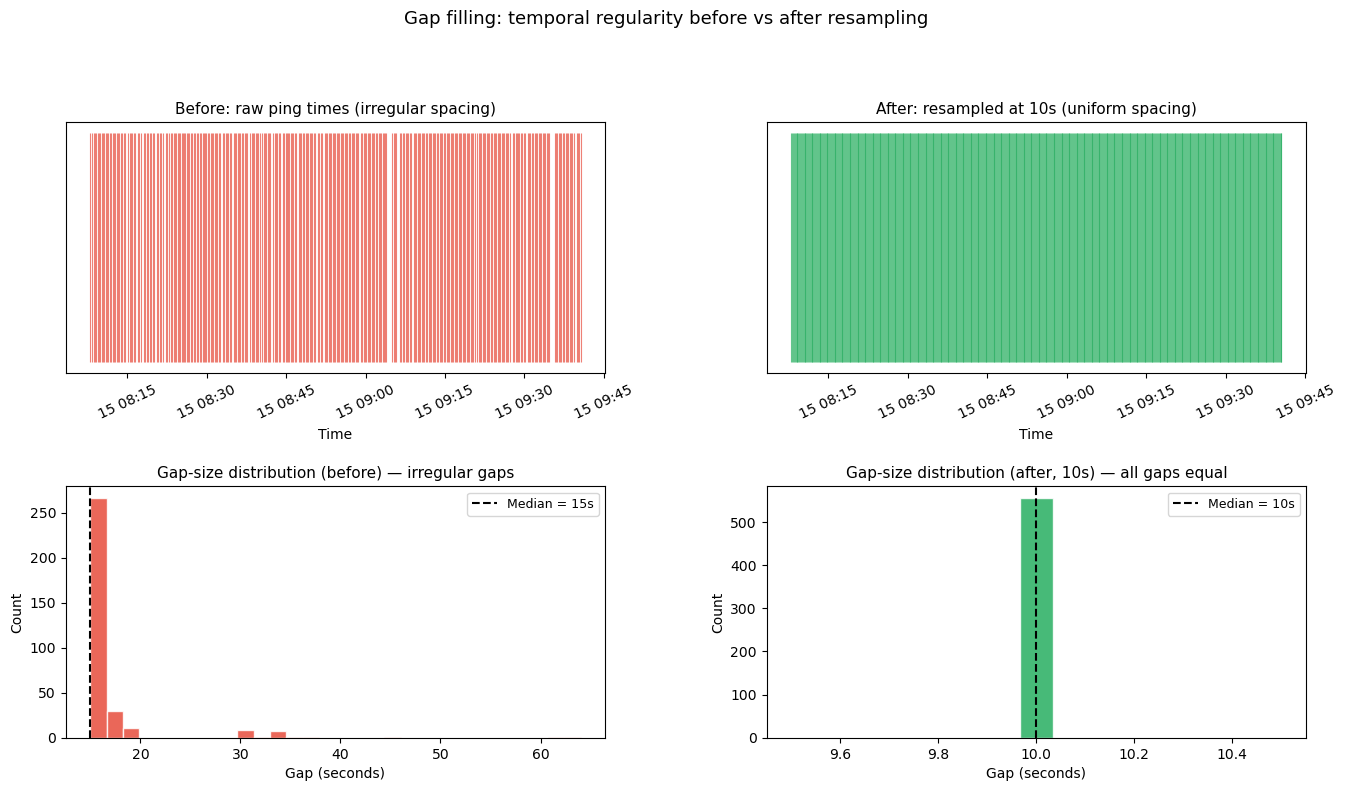

Saved: outputs/figs/gapfill_before_after.png


In [92]:
# 1) Resample one trajectory to fixed interval
t0i = t0.set_index("t").sort_index()

interval = "10s"  # try "5S", "10S", "30S"

t_rs = t0i.resample(interval).mean(numeric_only=True)
t_rs[["lat", "lon"]] = t_rs[["lat", "lon"]].interpolate()
t_rs = t_rs.reset_index()

print("Before rows:", t0i.shape[0], "After rows:", t_rs.shape[0])

# 2) 2x2 panel: rug plots + gap histograms
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 8),
    gridspec_kw={"hspace": 0.45, "wspace": 0.3},
)

before_times = t0i.index.to_series()
gaps_before = before_times.diff().dt.total_seconds().dropna()

after_idx = pd.to_datetime(t_rs["t"])
gaps_after = after_idx.diff().dt.total_seconds().dropna()

# ── Top-left: ping timeline BEFORE ───────────────────────────────
ax = axes[0, 0]
ax.vlines(
    before_times,
    0, 1,
    lw=0.8,
    alpha=0.7,
    color="#E74C3C",
)
ax.set_title(
    "Before: raw ping times (irregular spacing)",
    fontsize=11,
)
ax.set_xlabel("Time")
ax.set_yticks([])
ax.tick_params(axis="x", rotation=25)

# ── Top-right: ping timeline AFTER ───────────────────────────────
ax = axes[0, 1]
ax.vlines(
    after_idx,
    0, 1,
    lw=0.8,
    alpha=0.7,
    color="#27AE60",
)
ax.set_title(
    f"After: resampled at {interval} (uniform spacing)",
    fontsize=11,
)
ax.set_xlabel("Time")
ax.set_yticks([])
ax.tick_params(axis="x", rotation=25)

# ── Bottom-left: gap histogram BEFORE ─────────────────────────────
ax = axes[1, 0]
ax.hist(
    gaps_before,
    bins=30,
    color="#E74C3C",
    alpha=0.85,
    edgecolor="white",
)
ax.axvline(
    gaps_before.median(),
    color="black",
    lw=1.5,
    ls="--",
    label=f"Median = {gaps_before.median():.0f}s",
)
ax.set_title(
    "Gap-size distribution (before) — irregular gaps",
    fontsize=11,
)
ax.set_xlabel("Gap (seconds)")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

# ── Bottom-right: gap histogram AFTER ─────────────────────────────
ax = axes[1, 1]
ax.hist(
    gaps_after,
    bins=15,
    color="#27AE60",
    alpha=0.85,
    edgecolor="white",
)
ax.axvline(
    gaps_after.median(),
    color="black",
    lw=1.5,
    ls="--",
    label=f"Median = {gaps_after.median():.0f}s",
)
ax.set_title(
    f"Gap-size distribution (after, {interval}) — all gaps equal",
    fontsize=11,
)
ax.set_xlabel("Gap (seconds)")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

# ── Global title ──────────────────────────────────────────────────
fig.suptitle(
    "Gap filling: temporal regularity before vs after resampling",
    fontsize=13,
    y=1.02,
)

out = "outputs/figs/gapfill_before_after.png"

plt.tight_layout()
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out)

### 3.5 Trajectory visualizations (3 forms)

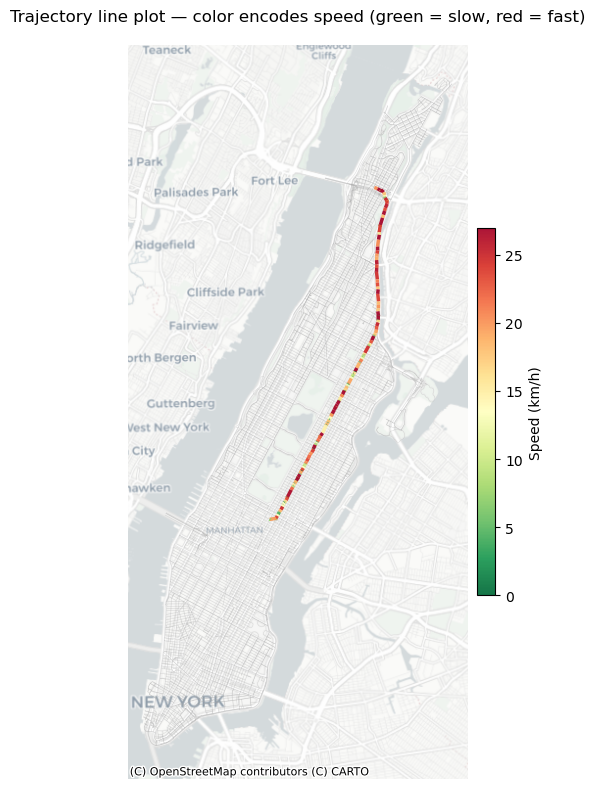

Saved: outputs/figs/trajectory_line.png


In [93]:
# 1) Trajectory line plot — segments colored by speed
# Save: outputs/figs/trajectory_line.png

from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
import numpy as np
from shapely.geometry import Point

# Sort trajectory
t0s = t0.sort_values("t").copy()

# Compute time difference
t0s["dt_s"] = t0s["t"].diff().dt.total_seconds()

# Previous coordinates
t0s["lon_prev"] = t0s["lon"].shift()
t0s["lat_prev"] = t0s["lat"].shift()

# Distance and speed
t0s["dist_m"] = haversine_m(
    t0s["lon_prev"],
    t0s["lat_prev"],
    t0s["lon"],
    t0s["lat"],
)

t0s["speed_kmh"] = (t0s["dist_m"] / t0s["dt_s"]) * 3.6

# Remove NaNs and invalid values
t0s = t0s.replace([np.inf, -np.inf], np.nan)
t0s = t0s.dropna(subset=["speed_kmh"])

# Convert to projected CRS
gpt_all = (
    gpd.GeoDataFrame(
        t0s,
        geometry=[Point(xy) for xy in zip(t0s["lon"], t0s["lat"])],
        crs="EPSG:4326",
    )
    .to_crs(edges_gdf.crs)
)

xs = gpt_all.geometry.x.values
ys = gpt_all.geometry.y.values
speeds = t0s["speed_kmh"].values

# Build line segments
segments = [
    [(xs[i], ys[i]), (xs[i + 1], ys[i + 1])]
    for i in range(len(xs) - 1)
]

seg_speeds = speeds[1:]

# ── Visual design knobs ─────────────────────────────────────────────
cmap_name = "RdYlGn_r"  # red=fast, green=slow
speed_vmax = np.percentile(seg_speeds, 95)
lw = 2.5
# ────────────────────────────────────────────────────────────────────

cmap = plt.get_cmap(cmap_name)
norm = mcolors.Normalize(vmin=0, vmax=speed_vmax)

lc = LineCollection(
    segments,
    cmap=cmap,
    norm=norm,
    linewidth=lw,
    alpha=0.92,
    zorder=4,
)

lc.set_array(seg_speeds)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

edges_gdf.plot(
    ax=ax,
    linewidth=0.4,
    alpha=0.35,
    color="#aaa",
)

ax.add_collection(lc)
ax.autoscale()

plt.colorbar(
    lc,
    ax=ax,
    shrink=0.5,
    label="Speed (km/h)",
    pad=0.01,
)

ctx.add_basemap(
    ax,
    crs=edges_gdf.crs,
    source=ctx.providers.CartoDB.Positron,
)

ax.set_title(
    "Trajectory line plot — color encodes speed (green = slow, red = fast)"
)

ax.set_axis_off()

out = "outputs/figs/trajectory_line.png"

plt.tight_layout()
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

In [96]:
# 2) Space-time cube (Plotly 3D) — trajectory tube colored by time
# Save: screenshot to outputs/figs/space_time_cube.png

import plotly.graph_objects as go
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# Convert to projected CRS
gpts_m = (
    gpd.GeoDataFrame(
        t0s,
        geometry=[Point(xy) for xy in zip(t0s["lon"], t0s["lat"])],
        crs="EPSG:4326",
    )
    .to_crs(edges_gdf.crs)
)

gpts_m["x"] = gpts_m.geometry.x
gpts_m["y"] = gpts_m.geometry.y

# Time in minutes since start
gpts_m["t_min"] = (
    pd.to_datetime(gpts_m["t"]) -
    pd.to_datetime(gpts_m["t"]).min()
).dt.total_seconds() / 60


# ── Visual design knobs ─────────────────────────────────────────────
colorscale = "Plasma"   # try "Viridis", "Turbo", "RdYlGn"
line_width = 4
marker_size = 3
# ────────────────────────────────────────────────────────────────────

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=gpts_m["x"],
        y=gpts_m["y"],
        z=gpts_m["t_min"],
        mode="lines+markers",
        line=dict(
            width=line_width,
            color=gpts_m["t_min"],
            colorscale=colorscale,
        ),
        marker=dict(
            size=marker_size,
            color=gpts_m["t_min"],
            colorscale=colorscale,
            showscale=True,
            colorbar=dict(
                title="Time (min)",
                thickness=15,
            ),
        ),
        name="Trajectory",
    )
)

bg = "#0f1117"

fig.update_layout(
    title="Space-time cube — trajectory tube colored by elapsed time",
    scene=dict(
        xaxis_title="Easting (m)",
        yaxis_title="Northing (m)",
        zaxis_title="Time (minutes)",
        bgcolor=bg,
        xaxis=dict(
            backgroundcolor=bg,
            gridcolor="#333",
        ),
        yaxis=dict(
            backgroundcolor=bg,
            gridcolor="#333",
        ),
        zaxis=dict(
            backgroundcolor=bg,
            gridcolor="#333",
        ),
    ),
    paper_bgcolor=bg,
    font=dict(color="white"),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()

gslow created: (203, 11)
CRS: EPSG:32618


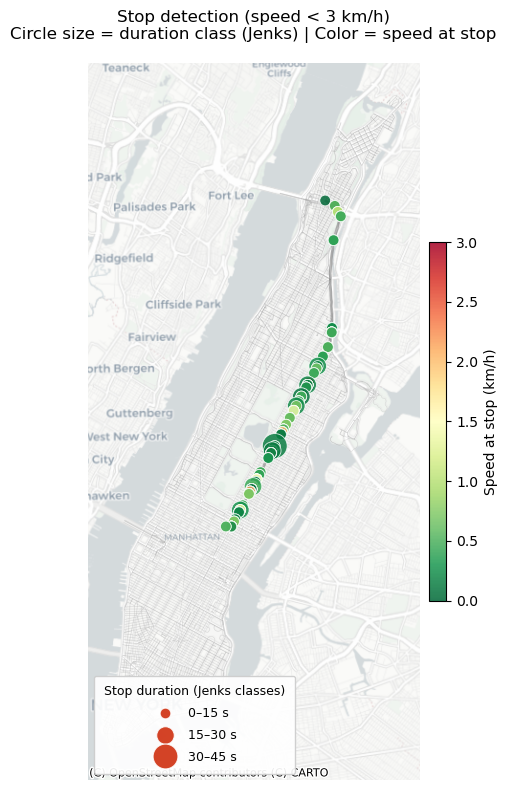

Saved: outputs/figs/stop_detection.png


In [97]:
# 3) Stop detection — stops sized by duration, colored by speed
# Save: outputs/figs/stop_detection.png

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import mapclassify as mc
from matplotlib.lines import Line2D

# -------------------------------------------------
# Assumptions:
# - t0 has columns ['t','lon','lat']
# - haversine_m() is defined
# - edges_gdf exists (projected CRS)
# - PING_INTERVAL_S defined
# - speed_thr defined (km/h threshold)
# -------------------------------------------------

# 1)Compute time delta, distance, speed
t0_speed = t0.sort_values("t").copy()
t0_speed["t"] = pd.to_datetime(t0_speed["t"], errors="coerce")

t0_speed["dt_s"] = t0_speed["t"].diff().dt.total_seconds()
t0_speed["lon_prev"] = t0_speed["lon"].shift()
t0_speed["lat_prev"] = t0_speed["lat"].shift()

t0_speed["dist_m"] = haversine_m(
    t0_speed["lon_prev"],
    t0_speed["lat_prev"],
    t0_speed["lon"],
    t0_speed["lat"],
)

t0_speed["speed_kmh"] = (
    t0_speed["dist_m"] /
    t0_speed["dt_s"].replace(0, np.nan)
) * 3.6


# 2) Filter slow / stop points
speed_thr = 3
slow_pts = t0_speed[
    (t0_speed["speed_kmh"] < speed_thr) |
    (t0_speed["speed_kmh"].isna())
].copy()


# 3) Define stop duration (seconds)
slow_pts["stop_dur_s"] = (
    slow_pts["dt_s"]
    .fillna(PING_INTERVAL_S)
    .clip(lower=0)
)


# 4) Create GeoDataFrame and project
gslow = (
    gpd.GeoDataFrame(
        slow_pts,
        geometry=gpd.points_from_xy(
            slow_pts["lon"],
            slow_pts["lat"]
        ),
        crs="EPSG:4326",
    )
    .to_crs(edges_gdf.crs)
)

print("gslow created:", gslow.shape)
print("CRS:", gslow.crs)


# -------------------------------------------------
# Visualization
# -------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

# Background
edges_gdf.plot(
    ax=ax,
    linewidth=0.4,
    alpha=0.35,
    color="#aaa"
)

gline_one = gpd.GeoSeries(
    [raw_line],
    crs=edges_gdf.crs
)

gline_one.plot(
    ax=ax,
    linewidth=2,
    alpha=0.4,
    color="#555",
    zorder=3
)


if len(gslow) > 0:

    # --- Jenks classification ---
    k = 4
    dur = gslow["stop_dur_s"].to_numpy()

    k_eff = int(min(k, len(dur), len(np.unique(dur))))
    k_eff = max(k_eff, 2)

    nb = mc.NaturalBreaks(dur, k=k_eff)
    gslow["dur_class"] = nb.yb

    # --- Marker sizes ---
    size_levels = np.array(
        [60, 160, 320, 520, 760][:k_eff]
    )

    gslow["markersize"] = size_levels[
        gslow["dur_class"].values
    ]

    # --- Scatter ---
    sc = ax.scatter(
        gslow.geometry.x,
        gslow.geometry.y,
        s=gslow["markersize"],
        c=gslow["speed_kmh"].fillna(0),
        cmap="RdYlGn_r",
        alpha=0.85,
        zorder=6,
        vmin=0,
        vmax=speed_thr,
        edgecolors="white",
        linewidths=0.6,
    )

    # Colorbar
    cb = fig.colorbar(
        sc,
        ax=ax,
        shrink=0.5,
        pad=0.01
    )
    cb.set_label("Speed at stop (km/h)")

    # --- Duration legend ---
    bins_hi = nb.bins
    bins_lo = np.r_[0, bins_hi[:-1]]

    def fmt_seconds_range(a, b):
        if b < 60:
            return f"{int(a)}–{int(b)} s"
        if a < 60 <= b:
            return f"{int(a)} s – {int(round(b/60))} min"
        return f"{int(round(a/60))}–{int(round(b/60))} min"

    handles = []

    for i in range(k_eff):
        ms_pts = float(np.sqrt(size_levels[i]))
        label = fmt_seconds_range(
            bins_lo[i],
            bins_hi[i]
        )

        handles.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="",
                markersize=ms_pts,
                markerfacecolor="#cc2200",
                markeredgecolor="white",
                markeredgewidth=0.8,
                alpha=0.85,
                label=label,
            )
        )

    ax.legend(
        handles=handles,
        title="Stop duration (Jenks classes)",
        loc="lower left",
        frameon=True,
        framealpha=0.92,
        borderpad=0.8,
        labelspacing=0.7,
        handletextpad=0.8,
        fontsize=9,
        title_fontsize=9,
    )

else:
    ax.text(
        0.5,
        0.5,
        "No stops detected",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=13,
        color="red",
    )


# Basemap
ctx.add_basemap(
    ax,
    crs=edges_gdf.crs,
    source=ctx.providers.CartoDB.Positron,
)

ax.set_axis_off()

ax.set_title(
    f"Stop detection (speed < {speed_thr} km/h)\n"
    "Circle size = duration class (Jenks) | Color = speed at stop"
)

out = "outputs/figs/stop_detection.png"

fig.tight_layout()
fig.savefig(out, dpi=200)

plt.show()

print("Saved:", out)